# EE 342 Final Project Lab Report  

**Team members:** Joanna Zhou, Yehoshua Luna, Noah Sanchez  

**Dataset used:** https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones  

## Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

## Helper Functions

In [ ]:
def compute_spectrograms(signal_tensor, n_fft=64, hop_length=4):
    """
    Converts a 3D time-series tensor into a 4D spectrogram tensor.
    
    Args:
        signal_tensor: Shape (Samples, TimeSteps, Channels) -> e.g., (7352, 128, 3)
        n_fft: The size of the sliding window for the mini-FFTs.
        hop_length: How many steps to slide the window forward each time.
        
    Returns:
        log_spectrogram: Shape (Samples, Channels, FreqBins, TimeFrames)
    """
    # PyTorch STFT expects the time dimension to be last
    # Convert shape from (Samples, 128, 3) to (Samples, 3, 128)
    signal_perm = signal_tensor.permute(0, 2, 1)
    
    # Create a Hann window to smooth the edges of the sliding slices
    window = torch.hann_window(n_fft).to(signal_tensor.device)
    
    # Compute the Short-Time Fourier Transform (STFT)
    stft_complex = torch.stft(
        signal_perm, 
        n_fft=n_fft, 
        hop_length=hop_length, 
        window=window, 
        return_complex=True
    )
    
    # Get magnitude of the complex spectrogram
    mag_spectrogram = torch.abs(stft_complex)
    
    # Convert to Log Scale (Decibels)
    # We add 1e-8 to prevent log(0) errors
    log_spectrogram = 20 * torch.log10(mag_spectrogram + 1e-8)
    
    return log_spectrogram

In [22]:
def plot_time_series(time_signal, title="Time Series", sample_rate=50):
    """
    Plots a 3-channel time-domain signal.
    
    Args:
        time_signal (torch.Tensor or np.ndarray): Time-domain signal with shape (Samples, Channels).
        title (str): Title for the plot.
        sample_rate (int): Sampling rate of the original signal in Hz (default is 50).
    
    Returns:
        None: Displays the plot of the time series.
    """
    # Convert to numpy if it's a PyTorch tensor
    if isinstance(time_signal, torch.Tensor):
        time_signal = time_signal.numpy()
        
    n_samples = time_signal.shape[0]
    time_axis = np.linspace(0, n_samples / sample_rate, n_samples)
    
    plt.figure(figsize=(12, 6))
    plt.plot(time_axis, time_signal)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend(['X-axis', 'Y-axis', 'Z-axis'], loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## Helper Classes

In [3]:
class HARDataLoader:
    """
    A management class for loading the UCI Human Activity Recognition Dataset.
    """
    
    def __init__(self, root_dir='data/raw'):
        """
        Initializes the loader with the root data directory.
        Uses pathlib for robust, cross-platform path handling. 
        
        Args:
            root_dir (str): Relative path to the raw data folder.
        """
        self.root = Path(root_dir)
        
    def _load_files_in_folder(self, folder_path, prefix, dataset_type):
        """
        Internal helper to combine X, Y, and Z axis text files into a 3D tensor.
        
        Args:
            folder_path (Path): Path to the 'Inertial Signals' directory.
            prefix (str): Signal type (e.g., 'total_acc' or 'body_gyro').
            dataset_type (str): 'train' or 'test'.
            
        Returns:
            torch.Tensor: A 3D tensor with shape (samples, 128, 3). [cite: 6]
        """
        axes = ['x', 'y', 'z']
        data = []
        
        for axis in axes:
            # Construct filename based on axis and split (e.g., total_acc_x_train.txt)
            file_name = f'{prefix}_{axis}_{dataset_type}.txt'
            file_path = folder_path / file_name
            
            if not file_path.exists():
                raise FileNotFoundError(f"Missing expected data file: {file_path}")
            
            # Load space-separated data into NumPy
            data_array = pd.read_csv(file_path, sep=r'\s+', header=None).values
            data.append(data_array)
            
        # Stack along the last dimension to create shape: (Samples, TimeSteps, Channels)
        # Convert to float32 for compatibility with PyTorch CNN layers
        return torch.tensor(np.stack(data, axis=-1), dtype=torch.float32)

    def get_split(self, split='train'):
        """
        Retrieves the accelerometer, gyroscope, and label tensors for a split.
        
        Args:
            split (str): The dataset partition to load ('train' or 'test').
            
        Returns:
            accel (Tensor): Total acceleration (including gravity). [cite: 8]
            gyro (Tensor): Body angular velocity. [cite: 6]
            labels (Tensor): 0-indexed activity labels (Long). [cite: 1, 3]
        """
        split_dir = self.root / split
        signal_dir = split_dir / 'Inertial Signals'
        
        # Load total accelerometer data (total acceleration = body + gravity)
        total_accel = self._load_files_in_folder(signal_dir, 'total_acc', split)
        
        # Load total accelerometer data (total acceleration = body + gravity)
        body_accel = self._load_files_in_folder(signal_dir, 'body_acc', split)

        # Load gyroscope data
        body_gyro = self._load_files_in_folder(signal_dir, 'body_gyro', split)
        
        # Load labels from y_train.txt or y_test.txt
        label_file = split_dir / f'y_{split}.txt'
        y_raw = pd.read_csv(label_file, sep=r'\s+', header=None).values
        
        # Flatten to 1D and shift labels 1-6 down to 0-5 for CrossEntropyLoss
        labels = torch.tensor(y_raw.squeeze(), dtype=torch.long) - 1
        
        return total_accel, body_accel, body_gyro, labels

## Loading Raw Data

In [4]:
loader = HARDataLoader('data/raw') # Initializes data loader to correct path

In [6]:
# Load training data and print shapes to verify
train_total_accel, train_body_accel, train_body_gyro, train_labels = loader.get_split('train')

print(f"Train total accel shape: {train_total_accel.shape}")
print(f"Train body accel shape: {train_body_accel.shape}")
print(f"Train body gyro shape: {train_body_gyro.shape}")
print(f"Train labels shape: {train_labels.shape}")

Train total accel shape: torch.Size([7352, 128, 3])
Train body accel shape: torch.Size([7352, 128, 3])
Train body gyro shape: torch.Size([7352, 128, 3])
Train labels shape: torch.Size([7352])


In [7]:
# Load test data and print shapes to verify
test_total_accel, test_body_accel, test_body_gyro, test_labels = loader.get_split('test')

print(f"Test total accel shape: {test_total_accel.shape}")
print(f"Test body accel shape: {test_body_accel.shape}")
print(f"Test body gyro shape: {test_body_gyro.shape}")
print(f"Test labels shape: {test_labels.shape}")

Test total accel shape: torch.Size([2947, 128, 3])
Test body accel shape: torch.Size([2947, 128, 3])
Test body gyro shape: torch.Size([2947, 128, 3])
Test labels shape: torch.Size([2947])


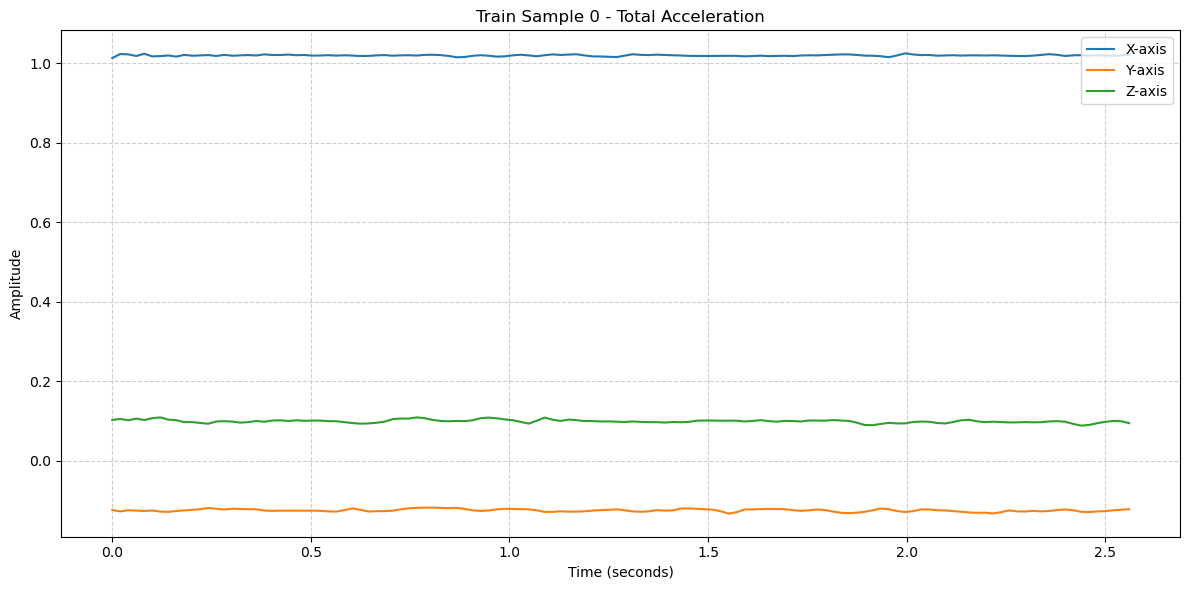

In [24]:
# Graph one sample of total accel data to visualize
plot_time_series(train_total_accel[0], title=f"Train Sample {0} - Total Acceleration")

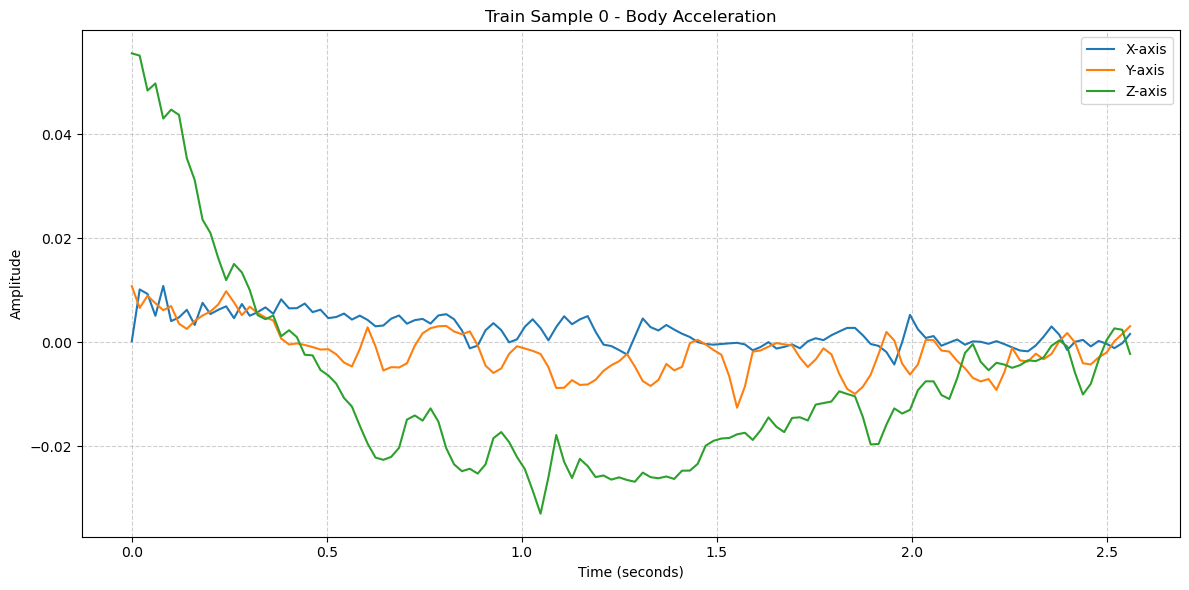

In [25]:
# Graph one sample of body accel data to visualize
plot_time_series(train_body_accel[0], title=f"Train Sample {0} - Body Acceleration")

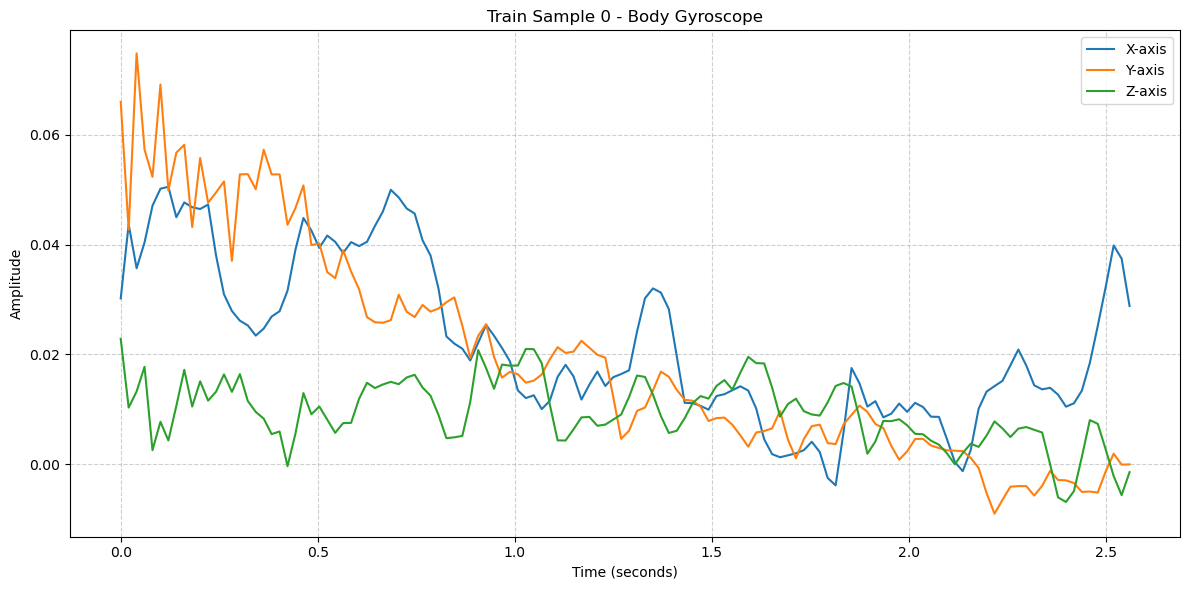

In [26]:
# Graph one sample of gyroscope data to visualize the time series
plot_time_series(train_body_gyro[0], title=f"Train Sample {0} - Body Gyroscope")

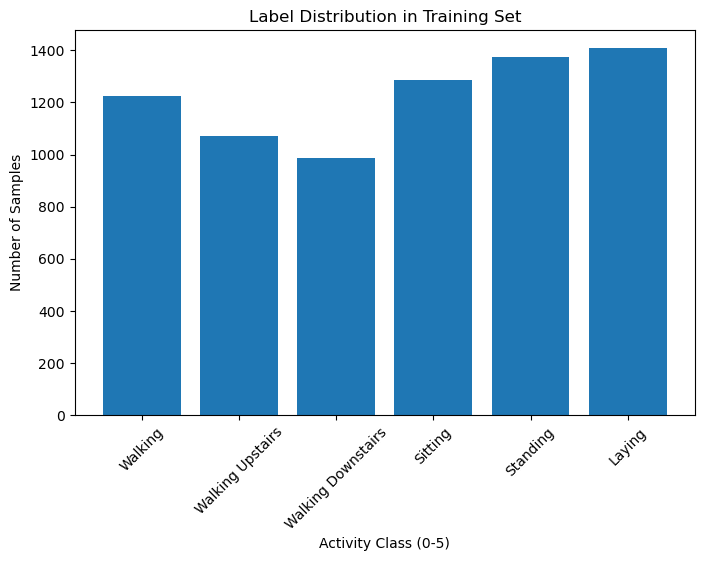

In [27]:
# Plot label distribution in training set to check for class imbalance
plt.figure(figsize=(8, 5))
label_counts = torch.bincount(train_labels)

plt.bar(range(6), label_counts.numpy())
plt.xlabel('Activity Class (0-5)')
plt.ylabel('Number of Samples')
plt.title('Label Distribution in Training Set')
plt.xticks(range(6), ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying'], rotation=45)
plt.show()

## Processing Data

In [13]:
# Calculate gravity acceleration by subtracting body acceleration from total acceleration.
train_gravity_accel = train_total_accel - train_body_accel
test_gravity_accel = test_total_accel - test_body_accel

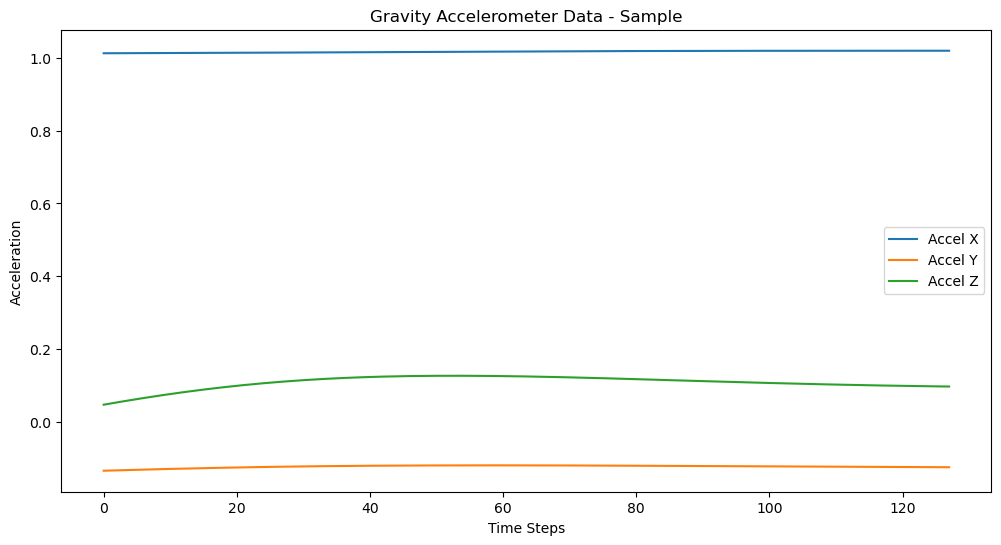

In [14]:
# Graph one sample gravity accel data to visualize
plt.figure(figsize=(12, 6))
time_steps = np.arange(train_gravity_accel.shape[1]) # 128 time steps

for i, axis in enumerate(['X', 'Y', 'Z']):
    plt.plot(time_steps, train_gravity_accel[0, :, i].numpy(), label=f'Accel {axis}')
    
plt.xlabel('Time Steps')
plt.ylabel('Acceleration')
plt.title('Gravity Accelerometer Data - Sample')
plt.legend()
plt.show()